# Seaborn – Mega Chuleta (EDA rápido y gráficos estadísticos)
> Seaborn es alto nivel sobre Matplotlib/Pandas para EDA con menos código y mejor estética.

## Configuración y carga de datos

In [2]:

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
sns.set_palette("deep")
tips = sns.load_dataset("tips")
penguins = sns.load_dataset("penguins")
print(tips.head())
print(penguins.head())


   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


## Gráficos univariantes (distribuciones)

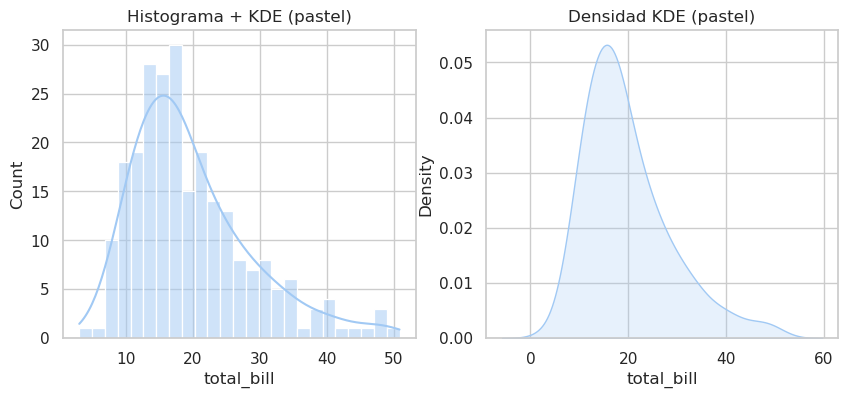

In [5]:

sns.set_palette("pastel")
fig, ax = plt.subplots(1,2, figsize=(10,4))
sns.histplot(data=tips, x="total_bill", bins=25, kde=True, ax=ax[0])
sns.kdeplot(data=tips, x="total_bill", fill=True, ax=ax[1])
ax[0].set_title("Histograma + KDE (pastel)")
ax[1].set_title("Densidad KDE (pastel)")
plt.show()


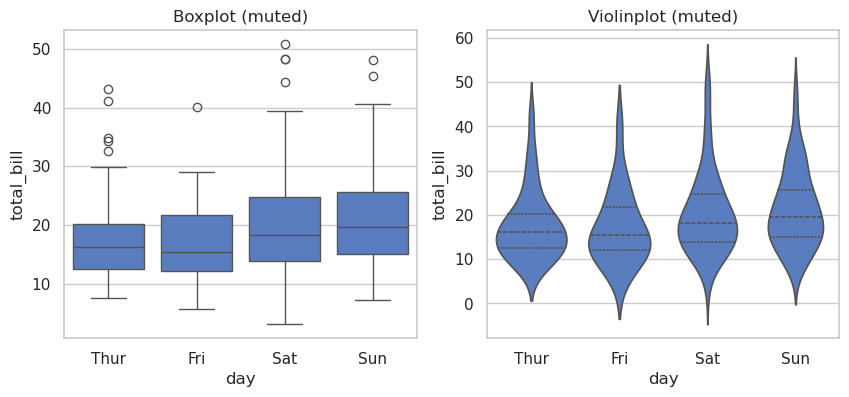

In [6]:

sns.set_palette("muted")
fig, ax = plt.subplots(1,2, figsize=(10,4))
sns.boxplot(data=tips, x="day", y="total_bill", ax=ax[0])
sns.violinplot(data=tips, x="day", y="total_bill", inner="quartile", ax=ax[1])
ax[0].set_title("Boxplot (muted)")
ax[1].set_title("Violinplot (muted)")
plt.show()


## Gráficos bivariantes y multivariantes

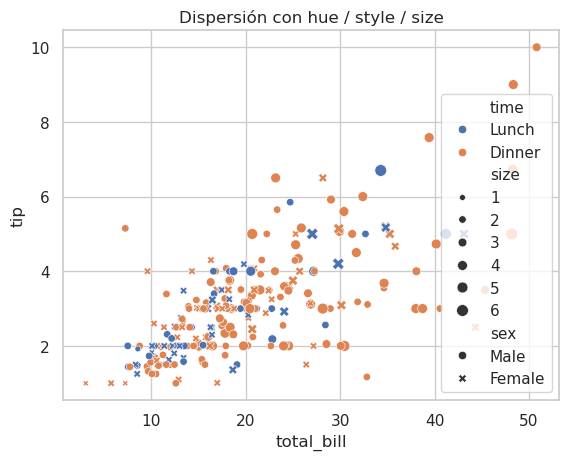

In [7]:

sns.set_palette("deep")
sns.scatterplot(data=tips, x="total_bill", y="tip",
                hue="time", style="sex", size="size")
plt.title("Dispersión con hue / style / size")
plt.show()


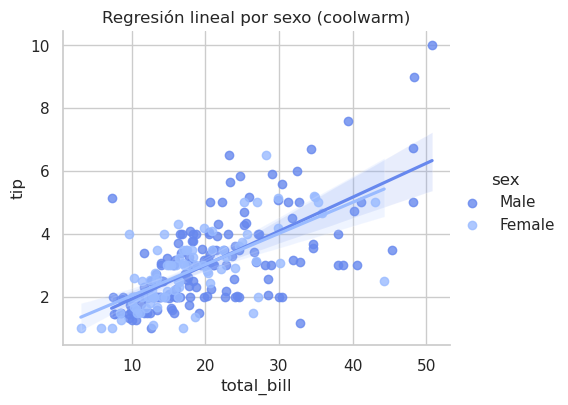

In [8]:

sns.set_palette("coolwarm")
sns.lmplot(data=tips, x="total_bill", y="tip", hue="sex", height=4, aspect=1.2)
plt.title("Regresión lineal por sexo (coolwarm)")
plt.show()


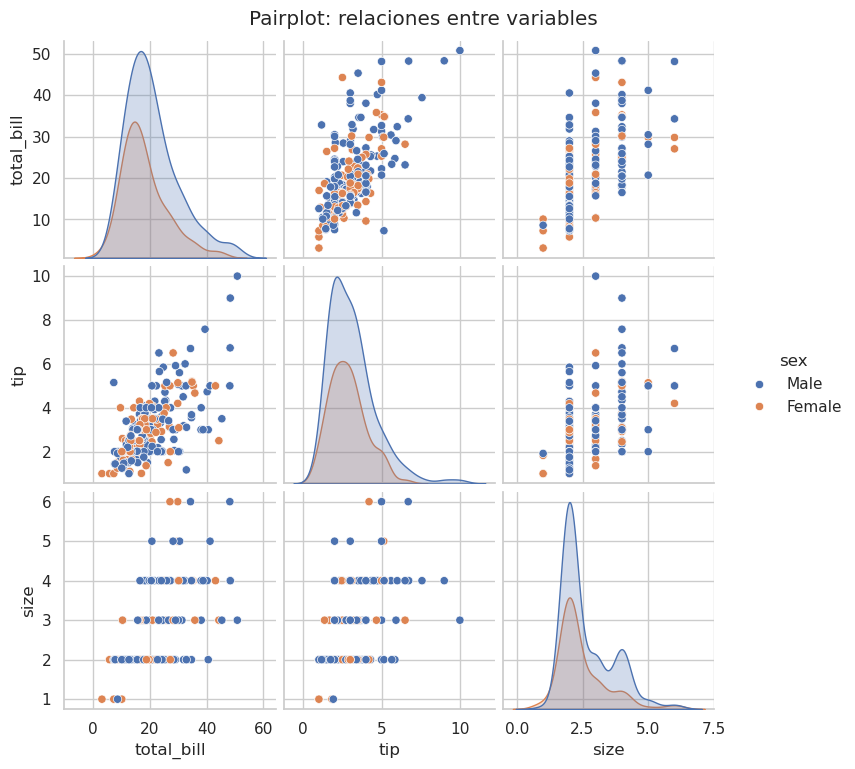

In [ ]:

sns.set_palette("deep")
sns.pairplot(data=tips, vars=["total_bill","tip","size"], hue="sex")
plt.suptitle("Pairplot: relaciones entre variables", y=1.02)
plt.show()


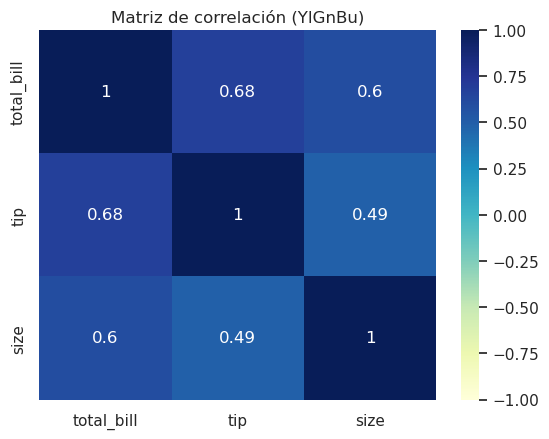

In [11]:

import numpy as np
corr = tips[["total_bill","tip","size"]].corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="YlGnBu", vmin=-1, vmax=1, center=0)
plt.title("Matriz de correlación (YlGnBu)")
plt.show()


## Gráficos categóricos y agregaciones

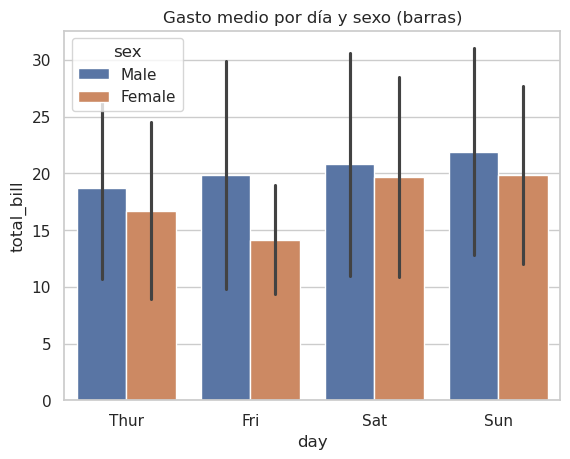

In [12]:

sns.set_palette("deep")
sns.barplot(data=tips, x="day", y="total_bill", hue="sex", estimator="mean", errorbar="sd")
plt.title("Gasto medio por día y sexo (barras)")
plt.show()


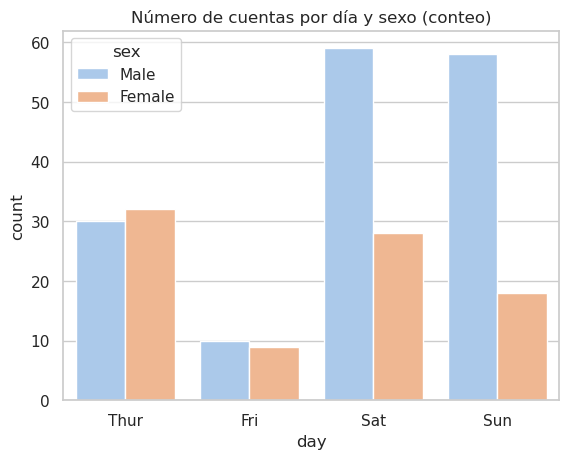

In [13]:

sns.set_palette("pastel")
sns.countplot(data=tips, x="day", hue="sex")
plt.title("Número de cuentas por día y sexo (conteo)")
plt.show()


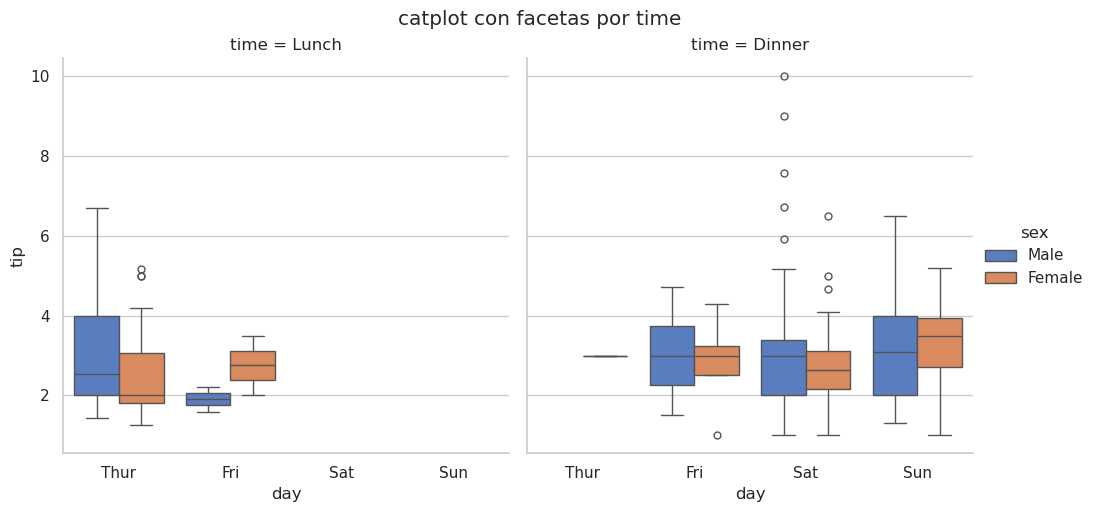

In [15]:

sns.set_palette("muted")
g = sns.catplot(data=tips, x="day", y="tip", hue="sex", kind="box", col="time")
g.figure.suptitle("catplot con facetas por time", y=1.02)
plt.show()


## Control visual básico y personalización ligera

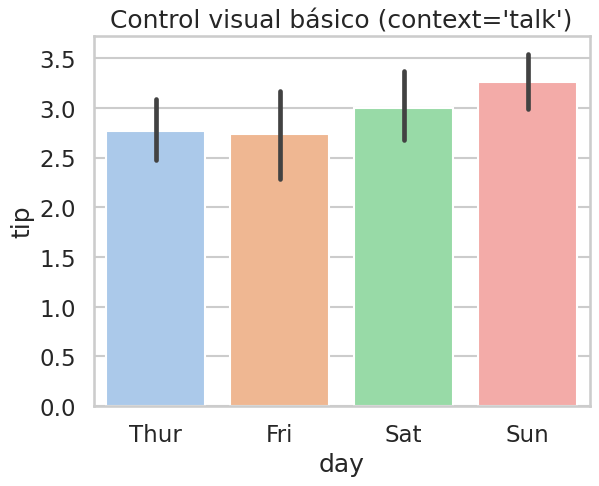

In [17]:

sns.set_theme(style="whitegrid", context="talk")
sns.barplot(data=tips, x="day", y="tip", hue="day", legend=False, palette="pastel")
plt.title("Control visual básico (context='talk')")
plt.show()


## Exportación y buenas prácticas

In [18]:

plt.tight_layout()
plt.savefig("seaborn_ejemplo.png", dpi=300, bbox_inches="tight")


<Figure size 640x480 with 0 Axes>

## Bonus: Mini‑EDA con `penguins`

In [20]:

sns.set_theme(style="whitegrid")
sns.set_palette("deep")
penguins.describe(include="all")
print(penguins.head())


  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


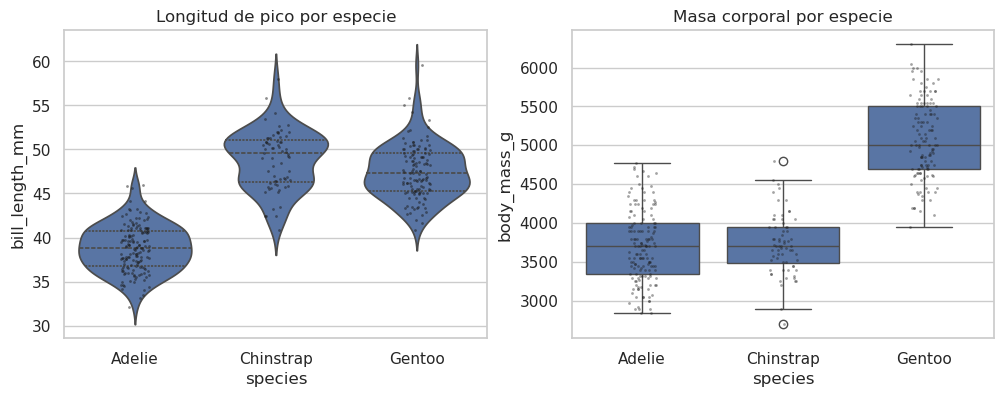

In [21]:

fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.violinplot(data=penguins, x="species", y="bill_length_mm", inner="quartile", ax=ax[0])
sns.stripplot(data=penguins, x="species", y="bill_length_mm", ax=ax[0], color="k", size=2, alpha=0.5)
ax[0].set_title("Longitud de pico por especie")

sns.boxplot(data=penguins, x="species", y="body_mass_g", ax=ax[1])
sns.stripplot(data=penguins, x="species", y="body_mass_g", color="k", size=2, alpha=0.4, ax=ax[1])
ax[1].set_title("Masa corporal por especie")
plt.show()


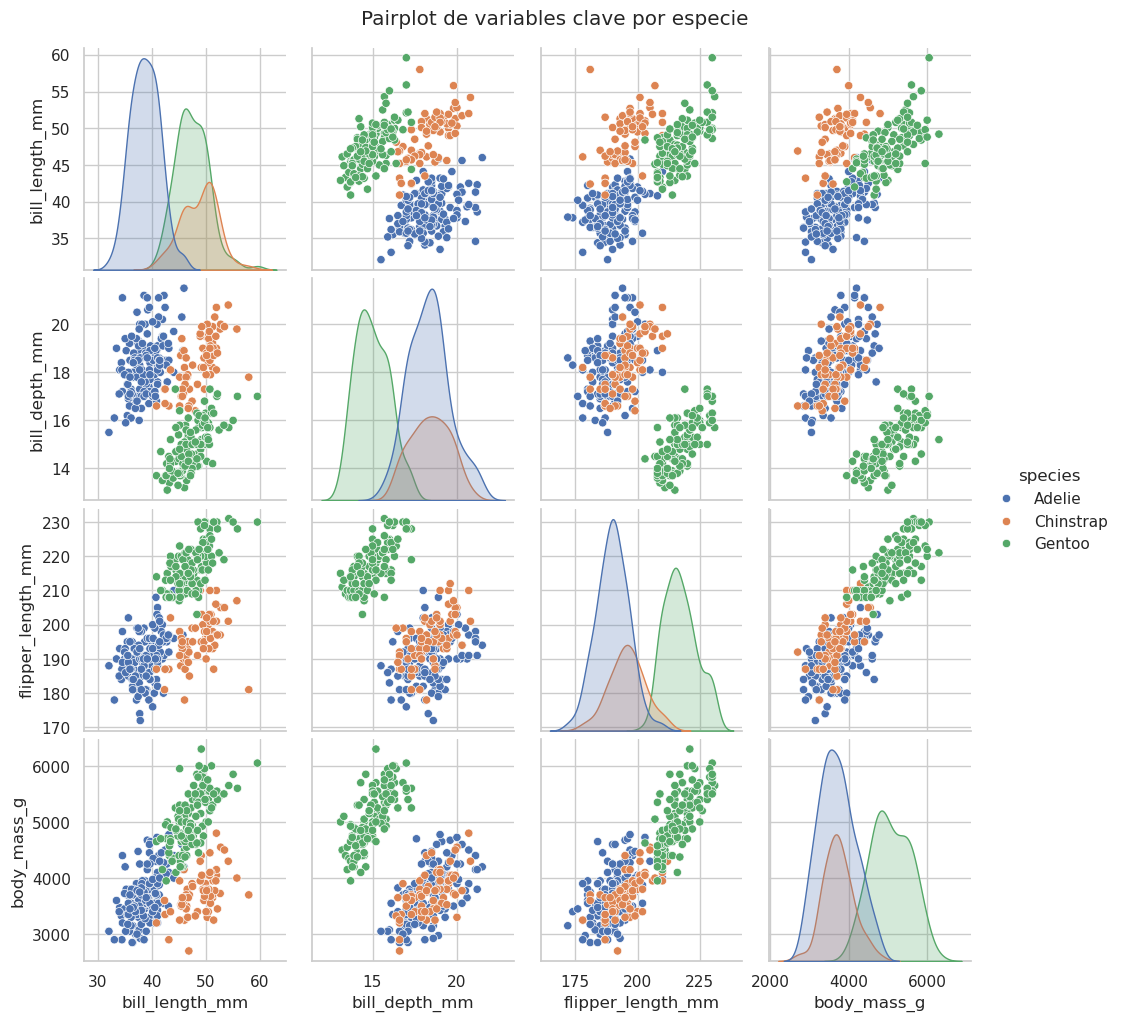

In [22]:

sns.pairplot(data=penguins, vars=["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"], hue="species")
plt.suptitle("Pairplot de variables clave por especie", y=1.02)
plt.show()


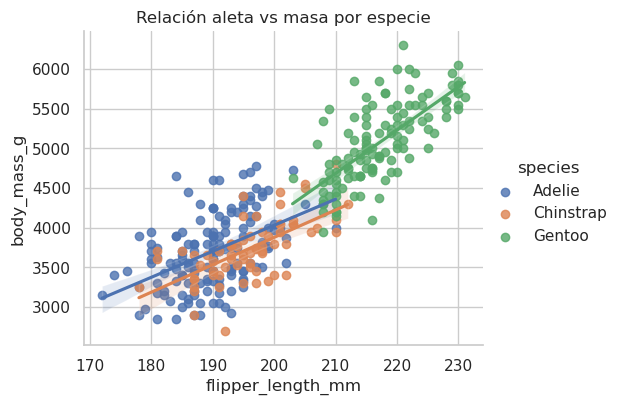

In [23]:

sns.lmplot(data=penguins, x="flipper_length_mm", y="body_mass_g", hue="species", height=4, aspect=1.3)
plt.title("Relación aleta vs masa por especie")
plt.show()


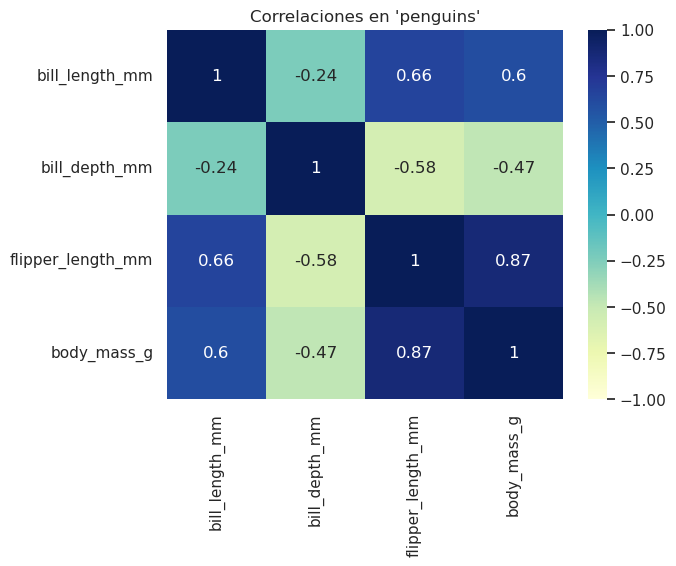

In [24]:

corr = penguins[["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]].corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="YlGnBu", vmin=-1, vmax=1, center=0)
plt.title("Correlaciones en 'penguins'")
plt.show()
